In [1]:
import sys
sys.path.append('..')
import utils

import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

from utils import one_hot
import selex_distribution, energy_models, tree, data_loading, training, callback, sampling, specialized_models

/home/scrotti/Aptamer2025py/experiments/../sampling.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
def hamming(x:torch.tensor, y: torch.tensor):
    L = x.size(-2)
    return L - (x * y).sum((-2, -1)).to(torch.int)

In [3]:
dtype = torch.float32

In [4]:
tr = tree.Tree()
tr.add_node(-1, name = "round 1 with selection")
tr.add_node(0, name = "round 2 with selection")

selected_modes = torch.BoolTensor(
    [[1, 0],
     [1, 0]]
)

n_selection_rounds, n_modes = selected_modes.size()
assert n_selection_rounds == tr.get_n_nodes()
n_rounds = n_selection_rounds + 1

In [5]:
L, q = 45, 4

In [6]:
generator = torch.Generator().manual_seed(1)
h_teacher = torch.randn(L, q, dtype=dtype, generator=generator)
wt_oh = sampling.sample_indep_sites(h_teacher, n_samples=1, generator=generator, beta=1.0).squeeze()
mutation_rate = 0.1
k_teacher = utils.field_from_wildtype(wt_oh, mutation_rate)
Ns0_teacher = energy_models.IndepSites(k_teacher)
sel_teacher = energy_models.IndepSites(h_teacher)
# sel.normalize()
unbound = energy_models.ConstantEnergy(-25.0)
ps_teacher = selex_distribution.MultiModeDistribution(sel_teacher, unbound, normalized=True)
model_teacher = selex_distribution.MultiRoundDistribution(Ns0_teacher, ps_teacher, tr, selected_modes)
model_teacher.train(mode=False);

## More accurate sampling

In [61]:
sample_round_zero = lambda n: sampling.sample_indep_sites(k_teacher, n)
def ps_round_t(x, t):
    return torch.exp(-ps_teacher.compute_energy(x, selected_modes[t]).detach())

total_reads = torch.tensor([0, 1, 2]) + 10**5
initial_pop_size = 10**6

In [55]:
# seq_round_zero = sample_round_zero(initial_pop_size)
# sequences, counts_round_zero = torch.unique(seq_round_zero, dim=0, return_counts=True)

In [56]:
# import timeit

# def foo(initial_pop_size):
#     seq_round_zero = sample_round_zero(initial_pop_size)
#     sequences, counts_round_zero = torch.unique(seq_round_zero, dim=0, return_counts=True)
#     return len(sequences)

# popsizes = [10**d for d in [1,2,3,4,5,6]]

# times = []
# n_unique = []
# for popsize in popsizes:
#     print(f'Measuring size {popsize}...')
#     t = %timeit -o foo(popsize)
#     times.append(t.best)
#     n = foo(popsize)
#     n_unique.append(n)

In [57]:
# plt.plot(popsizes, times, marker='o')
# plt.xlabel('Population size')
# plt.ylabel('Execution time [s]')
# plt.xscale('log')
# plt.yscale('log')

In [58]:
# plt.plot(popsizes, n_unique, marker='o')
# plt.xlabel('Population size')
# plt.ylabel('Number of unique sequences')
# plt.xscale('log')
# plt.yscale('log')

In [177]:
def read_multinomial(population, total_reads, sequences):
    reads_idx = []
    for t in range(len(population)):
        reads_t = torch.multinomial(population[t].to(torch.float), total_reads[t], replacement=True)
        reads_idx.append(reads_t)
    sequences_oh = [sequences[id] for id in reads_idx]
    
    return sequences_oh

def read_negbin(population, total_reads, sequences, r):
    sequences_oh = []
    for t in range(len(population)):
        pt = population[t].to(torch.float)
        pt = pt / pt.sum()
        rt = torch.full(pt.size(), r)
        read_counts_t = torch.distributions.negative_binomial.NegativeBinomial(rt, pt).sample().to(torch.int)
        sequences_t = torch.repeat_interleave(sequences, read_counts_t, dim=0)
        sequences_oh.append(sequences_t)

    return sequences_oh

def ReadNegBin(r):
    def _read(*args):
        return read_negbin(*args, r)
    return _read

def read_poisson(population, total_reads, sequences):
    sequences_oh = []
    for t in range(len(population)):
        normalized_population_t = population[t].to(torch.float) / population[t].sum()
        poisson_mean = normalized_population_t * total_reads[t]
        read_counts_t = torch.poisson(poisson_mean).to(torch.int)
        sequences_t = torch.repeat_interleave(sequences, read_counts_t, dim=0)
        sequences_oh.append(sequences_t)

    return sequences_oh
    
def sample_realistic(
    sample_round_zero,
    ps_round_t,
    initial_pop_size: int,
    total_reads: torch.tensor,
    population = [],
    read = read_multinomial,
    verbose = True
):
    seq_round_zero = sample_round_zero(initial_pop_size)
    if verbose: print("Extracting unique sequences and counts from initial library...")
    sequences, counts_round_zero = torch.unique(seq_round_zero, dim=0, return_counts=True)
    ps = [ps_round_t(sequences, t) for t in range(n_selection_rounds)]
    if not torch.all(torch.tensor([torch.all(pst <= 1) for pst in ps])):
        raise ValueError(f'Got some selection probabilities > 1')
    population.append(counts_round_zero.to(torch.int64))
    for t in range(1, n_rounds):
        if verbose: print(f"Starting selection round {t} of {n_rounds-1}...")
        d = torch.distributions.Binomial(population[t-1], ps[t-1])
        selected = d.sample()
        if not torch.all(selected >= 0):
            raise ValueError("Binomial sampled negative values")
        amplification = 1 / ps[t-1].mean()
        population_t = (selected * amplification).to(torch.int64)
        if not torch.all(population_t >= 0):
            raise ValueError("Negative population value")
        if torch.all(population_t == 0):
            raise ValueError(f"Nothing was selected at round {t}")
        population.append(population_t)

    sequences_oh = read(population, total_reads, sequences)
    
    return sequences, population, sequences_oh

In [178]:
r = 10**5

population = []
sequences, population, sequences_oh = sample_realistic(
    sample_round_zero,
    ps_round_t,
    initial_pop_size,
    total_reads,
    population,
    read = ReadNegBin(r)
)

Extracting unique sequences and counts from initial library...
Starting selection round 1 of 2...
Starting selection round 2 of 2...


In [179]:
idx = population[1].argmax(0).item()
hamming(sequences[idx], wt_oh)

tensor(1, dtype=torch.int32)

In [180]:
[pop.to(dtype).mean() for pop in population]

[tensor(1.2263), tensor(1.1942), tensor(94.2567)]

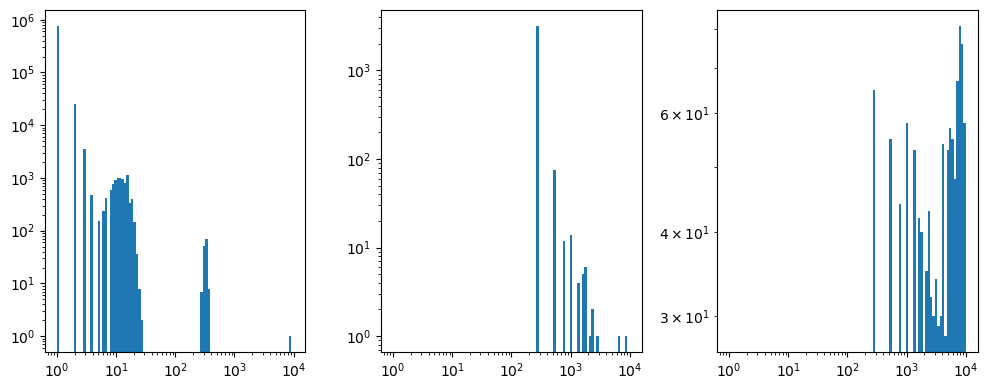

In [181]:
fig, axes = plt.subplots(1, n_rounds, figsize=(10,4))

for t in range(n_rounds):
    ax = axes[t]
    ax.hist(population[t], bins=np.logspace(0, 4, 100))
    ax.set_yscale('log')
    ax.set_xscale('log')

fig.tight_layout()

## Learn

In [182]:
# from importlib import reload
# reload(callback)
# reload(data_loading)
# reload(energy_models)
# reload(selex_distribution)

In [183]:
total_reads = torch.tensor([s.shape[0] for s in sequences_oh])

In [184]:
k = torch.zeros(L, q, dtype=dtype)
h = torch.zeros(L, q, dtype=dtype)

model = specialized_models.IndepSitesMultiRoundDistribution(k, h, n_rounds)
model.cache_site_frequencies(sequences_oh)

In [185]:
data_loaders = [data_loading.SelexRoundDataLoader(sequences_oh[id], batch_size=1) for id in range(n_rounds)]
chains = training.init_chains(n_rounds, 1, L, q, dtype=dtype)

In [186]:
callbacks = [callback.ConvergenceMetricsCallback(), callback.TeacherStudentCallback(model_teacher)]

In [187]:
n_sweeps = 10
lr = 0.5
max_epochs = 10**3

training.train(model, data_loaders, total_reads, chains, n_sweeps, max_epochs, lr=lr, callbacks=callbacks)

 0.00%[                                                                                                       …

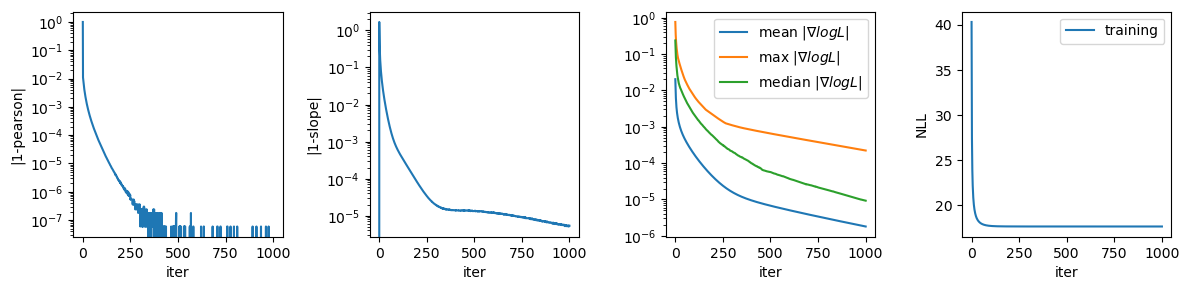

In [188]:
callbacks[0].plot();

INDEP SITES


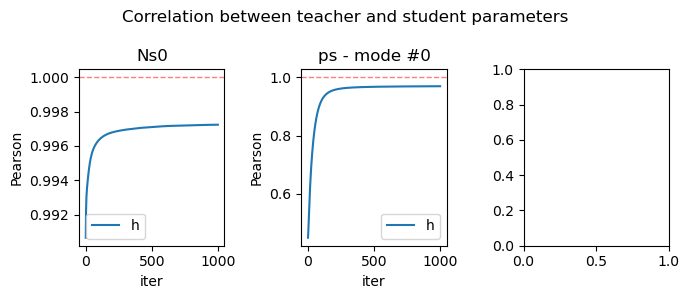

In [189]:
callbacks[1].plot(figsize=(7,3))
print('INDEP SITES')

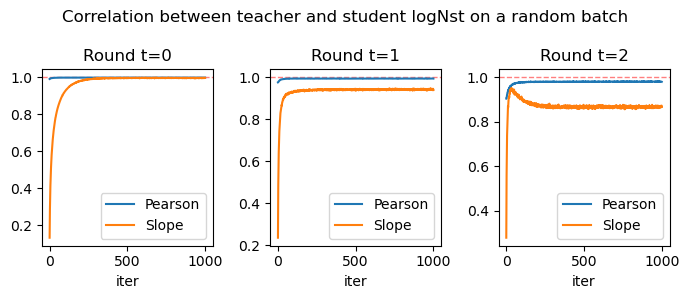

In [190]:
callbacks[1].plot_pearson_energies(figsize=(7,3));

0.9972401857376099

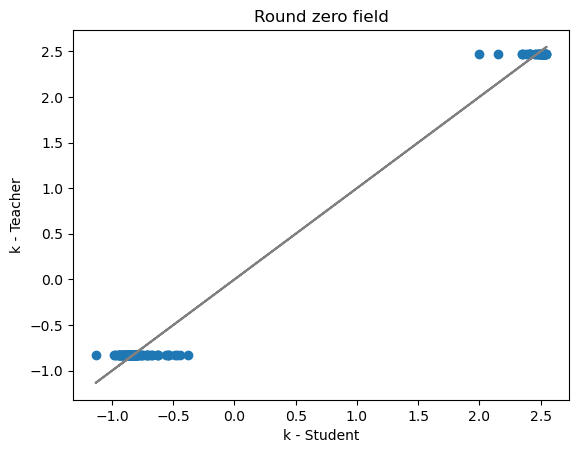

In [191]:
X = model.round_zero.set_zerosum_gauge().h.detach().reshape(-1)
Y = model_teacher.round_zero.set_zerosum_gauge().h.detach().reshape(-1)
plt.scatter(X, Y)
plt.plot(X, X, color='gray')
plt.xlabel('k - Student'); plt.ylabel('k - Teacher')
plt.title('Round zero field')
utils.compute_pearson(X, Y)

0.9695692658424377

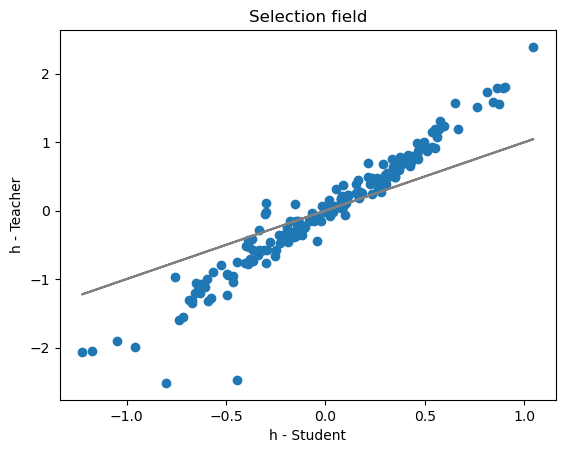

In [192]:
X = model.selection.modes[0].set_zerosum_gauge().h.detach().reshape(-1)
Y = model_teacher.selection.modes[0].set_zerosum_gauge().h.detach().reshape(-1)
plt.scatter(X, Y)
plt.plot(X, X, color='gray')
plt.xlabel('h - Student'); plt.ylabel('h - Teacher')
plt.title('Selection field')
utils.compute_pearson(X, Y)

## Effect of negative binomial

In [ ]:
def generate_multinomial(sample_round_zero, ps_round_t, initial_pop_size, total_reads):
    population = []
    sequences, population, sequences_oh = sample_realistic(
        sample_round_zero,
        ps_round_t,
        initial_pop_size,
        total_reads,
        population,
        read = read_multinomial
    )
    return sequences_oh

def generate_negbin(sample_round_zero, ps_round_t, initial_pop_size, total_reads, r):
    population = []
    sequences, population, sequences_oh = sample_realistic(
        sample_round_zero,
        ps_round_t,
        initial_pop_size,
        total_reads,
        population,
        read = ReadNegBin(r)
    )
    return sequences_oh

def generate_poisson(sample_round_zero, ps_round_t, initial_pop_size, total_reads):
    population = []
    sequences, population, sequences_oh = sample_realistic(
        sample_round_zero,
        ps_round_t,
        initial_pop_size,
        total_reads,
        population,
        read = read_poisson
    )
    return sequences_oh

def train(sequences_oh, model_teacher):
    L, q = sequences_oh[0][0].size()
    dtype = sequences_oh[0].dtype
    n_rounds = len(sequences_oh)
    k = torch.zeros(L, q, dtype=dtype)
    h = torch.zeros(L, q, dtype=dtype)
    model = specialized_models.IndepSitesMultiRoundDistribution(k, h, n_rounds)
    model.cache_site_frequencies(sequences_oh)
    data_loaders = [data_loading.SelexRoundDataLoader(sequences_oh[id], batch_size=1) for id in range(n_rounds)]
    chains = training.init_chains(n_rounds, 1, L, q, dtype=dtype)
    callbacks = [callback.ConvergenceMetricsCallback(progress_bar=False), callback.TeacherStudentCallback(model_teacher)]
    n_sweeps = 10
    lr = 0.5
    max_epochs = 10**4
    training.train(model, data_loaders, total_reads, chains, n_sweeps, max_epochs, lr=lr, 
                   target_pearson=1-1e-5, callbacks=callbacks)

    return model, callbacks

def generate_and_train_multinomial(sample_round_zero, ps_round_t, initial_pop_size, total_reads, model_teacher):
    sequences_oh = generate_multinomial(sample_round_zero, ps_round_t, initial_pop_size, total_reads)
    model, callbacks = train(sequences_oh, model_teacher)
    
    return model, callbacks

def generate_and_train_negbin(sample_round_zero, ps_round_t, initial_pop_size, total_reads, model_teacher, r):
    sequences_oh = generate_negbin(sample_round_zero, ps_round_t, initial_pop_size, total_reads, r)
    model, callbacks = train(sequences_oh, model_teacher)
    
    return model, callbacks

def generate_and_train_poisson(sample_round_zero, ps_round_t, initial_pop_size, total_reads, model_teacher):
    sequences_oh = generate_poisson(sample_round_zero, ps_round_t, initial_pop_size, total_reads)
    model, callbacks = train(sequences_oh, model_teacher)
    
    return model, callbacks

In [157]:
model_multinom, callbacks_multinom = generate_and_train_multinomial(sample_round_zero, ps_round_t, initial_pop_size, total_reads, model_teacher)

Extracting unique sequences and counts from initial library...
Starting selection round 1 of 2...
Starting selection round 2 of 2...


 0.00%[                                                                                                       …

In [163]:
model_poisson, callbacks_poisson = generate_and_train_poisson(sample_round_zero, ps_round_t, initial_pop_size, total_reads, model_teacher)

Extracting unique sequences and counts from initial library...
Starting selection round 1 of 2...
Starting selection round 2 of 2...


 0.00%[                                                                                                       …

In [ ]:
rs = [10, 100, 1000, 10**4, 10**5, 10**6, 10**7, 10**8]

models_negbin = []
callbacks_negbin = []

for r in rs:
    m, c = generate_and_train_negbin(sample_round_zero, ps_round_t, initial_pop_size, total_reads, model_teacher,r)
    models_negbin.append(m)
    callbacks_negbin.append(c)

Extracting unique sequences and counts from initial library...
Starting selection round 1 of 2...
Starting selection round 2 of 2...


 0.00%[                                                                                                       …

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter serve

Extracting unique sequences and counts from initial library...
Starting selection round 1 of 2...
Starting selection round 2 of 2...


 0.00%[                                                                                                       …

...

Extracting unique sequences and counts from initial library...
Starting selection round 1 of 2...
Starting selection round 2 of 2...


 0.00%[                                                                                                       …

Extracting unique sequences and counts from initial library...
Starting selection round 1 of 2...
Starting selection round 2 of 2...


 0.00%[                                                                                                       …

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [ ]:
def extract_pearsons(callbacks):
    return callbacks[1].pearson_Ns0[-1][0], callbacks[1].pearson_ps[-1][0][0]

In [ ]:
for (r, callbacks) in zip(rs, callbacks_negbin):
    print(f'r={r}')
    callbacks[1].plot()

In [ ]:
pearson_multinom = extract_pearsons(callbacks_multinom)
pearson_poisson = extract_pearsons(callbacks_poisson)
pearson_negbin = [extract_pearsons(c) for c in callbacks_negbin]

In [ ]:
fig, axes = plt.subplots(2,1, figsize=(10,6))

y = ['Ns0', 'ps']
for i in range(2):
    ax = axes[i]
    ax.bar(['multinom'], pearson_multinom[i])
    ax.bar(['poisson'], pearson_poisson[i])
    for a in range(len(pearson_negbin)):
        ax.bar([f'neg bin r={rs[a]}'], pearson_negbin[a][i])
    ax.set_ylabel(f'Pearson wrt teacher')
    ax.set_title(f'Indep sites field {y[i]}')
fig.tight_layout()

## Compare against data

In [44]:
sequences_unique_all_oh, counts_unique, enrichments = utils.group_rounds(sequences_oh, return_enrichments=True)

Extracting unique sequences and counts at each round...
Merging sequences from all rounds in a single container...
Assigning counts at each round to unique sequences...
	Starting round 0...
	Starting round 1...
	Starting round 2...
Calculating enrichments...
Finished


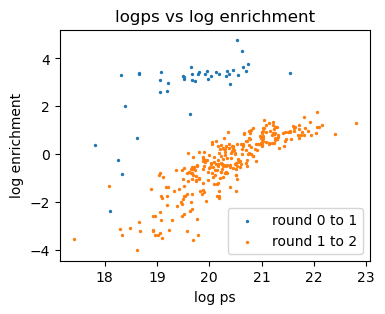

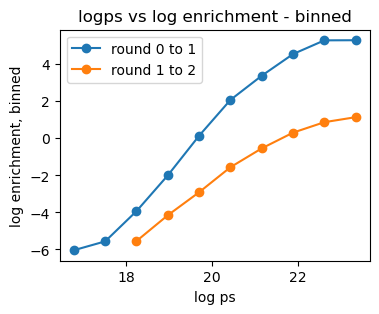

In [45]:
utils.binned_logenrichments(model, sequences_unique_all_oh, enrichments, counts_unique, n_bins = 25, plot=True, thresh=0.0);

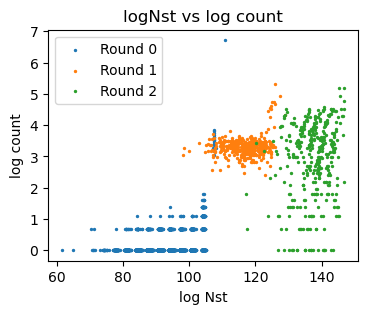

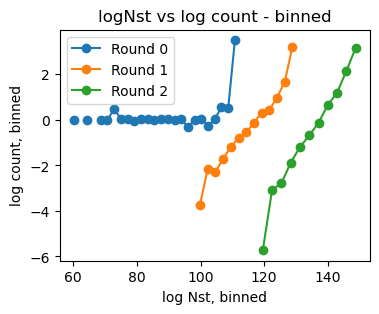

In [46]:
utils.binned_logcounts(model, sequences_unique_all_oh, counts_unique, n_bins = 25, plot=True, thresh=0.0);